# Tutorial 08 — Balanced vs Unbalanced Filter Families

Two filter families are bundled with the package:

* **Balanced** — `η_0 = η_1 = 5/2` (equal energy split). Larger d² for parallel single-bit `b_1` flips, smaller stream-0 free distance.
* **Unbalanced** — `η_0 ≠ η_1`, optimised to maximise stream-0 free distance. Wins under the paper's MSED metric.

This tutorial places them side by side on three axes: filter shape, MSED, and uncoded BER.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nsm.modem.msprs import precompute, uncoded_ber
from nsm.bounds import min_squared_distance_stream0, parallel_min_squared_distance

## Filter shape

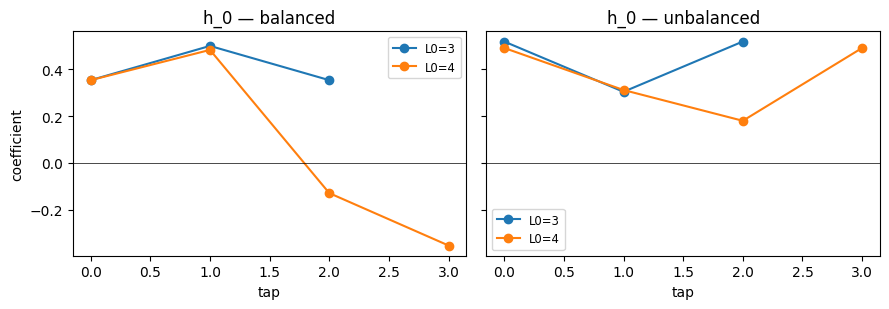

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, ft in zip(axes, ('balanced', 'unbalanced')):
    for L0 in (3, 4):
        p = precompute(L0, 1000, ft)
        ax.plot(p['h0'], 'o-', label=f'L0={L0}')
    ax.axhline(0, color='k', lw=0.5); ax.set_title(f'h_0 — {ft}')
    ax.set_xlabel('tap'); ax.legend(fontsize='small')
axes[0].set_ylabel('coefficient'); plt.tight_layout()

## MSED comparison

In [3]:
for L0 in (3, 4):
    bal = precompute(L0, 1000, 'balanced'); unb = precompute(L0, 1000, 'unbalanced')
    print(f'L0={L0} | stream-0 MSED: balanced={min_squared_distance_stream0(bal):5.3f}  '
          f'unbalanced={min_squared_distance_stream0(unb):5.3f} | '
          f'4·h1² balanced={parallel_min_squared_distance(bal):5.3f} '
          f'unbalanced={parallel_min_squared_distance(unb):5.3f}')

L0=3 | stream-0 MSED: balanced=1.843  unbalanced=3.968 | 4·h1² balanced=2.000 unbalanced=1.478
L0=4 | stream-0 MSED: balanced=3.108  unbalanced=3.931 | 4·h1² balanced=2.000 unbalanced=1.552


## Uncoded BER at one SNR
MS-PRS unbalanced delivers higher MSED but it's the *full joint* MSED (i.e. `min_squared_distance(p)`) that dominates the uncoded equalizer's high-SNR floor — and balanced wins there. So which is *better* depends on whether you run an outer code (favours unbalanced via stream-0 MSED) or use the modem stand-alone.

In [4]:
L0, src, snr = 3, 4096, 10.0
nv = 0.5 / (2 * 10 ** (snr / 10))
for ft in ('balanced', 'unbalanced'):
    p = precompute(L0, src, ft)
    total = sum(int(uncoded_ber(src, L0, p['h0'], p['h1'], p['branch_labels'],
                                 p['memory'], p['total_states'], p['next_states'],
                                 p['branch_indices'], nv, np.sqrt(nv))) for _ in range(5))
    print(f'L0={L0} {ft:11s}  uncoded BER @ {snr} dB = {total / (5 * src):.4f}')

L0=3 balanced     uncoded BER @ 10.0 dB = 0.0020
L0=3 unbalanced   uncoded BER @ 10.0 dB = 0.0200
